# PDSCNN — Standalone Training (50 Epochs)

This notebook trains **only the PDSCNN branch** (no ViT, no RRELM, no fusion) from scratch, targeting the highest achievable standalone accuracy on the 4-class brain tumor MRI task (`glioma`, `meningioma`, `notumor`, `pituitary`).

Because the data is pooled from **multiple sources**, the preprocessing pipeline is built to remove cross-source inconsistency before the model ever sees the data:

| Stage | Purpose |
|---|---|
| 1. Source-aware loading | Merges `data.zip`, `data1.zip`, and `data2.zip` class-wise, tagging every image with which zip it came from |
| 2. Deduplication (perceptual hashing) | Removes exact/near-duplicate images that different sources often share, which would otherwise leak across train/val/test |
| 2a. Quality gate | Drops corrupt, unreadably small, blurry, or blank/low-information images before anything is selected for training |
| 2b. Strict fixed-size selection | From the deduped, quality-passed pool, keeps exactly the **12,500** most-unique images (class-balance preserving) |
| 3. Grayscale standardization | MRI scans should carry no color information; forces every source onto the same footing |
| 4. Brain-region autocrop | Strips black borders / scanner annotations that differ by source |
| 5. Denoising | Reduces scanner-specific sensor noise |
| 6. CLAHE | Normalizes contrast differences between scanners/sources |
| 7. Resize to 224×224 | Uniform input size |
| 8. Dataset-specific normalization | Mean/std computed on *this* processed dataset (not ImageNet, since PDSCNN trains from scratch) |
| 9. Augmentation (train only) | Flips, rotation, translation, zoom, brightness/contrast jitter |

Every preprocessing stage below shows before/after images so you can sanity-check it on your own data before committing to a 50-epoch run.

**Outputs saved to Google Drive:** best checkpoint, final checkpoint, full config (class map + normalization stats), training curves, confusion matrix, and the processed image cache.


## 0. Setup

In [30]:
!pip install -q imagehash grad-cam >/dev/null
print("Installed extra deps: imagehash, grad-cam")


Installed extra deps: imagehash, grad-cam


In [31]:
import os, glob, shutil, random, zipfile, json, time, hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              confusion_matrix, classification_report)

import imagehash

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)
if device.type == 'cuda':
    print("GPU:", torch.cuda.get_device_name(0))

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True


Device: cuda
GPU: Tesla T4


## 1. Load Data (multi-source aware)

Three known zips are merged **class-wise**: `/content/drive/MyDrive/data.zip`, `/content/drive/MyDrive/data1.zip`, and `/content/drive/MyDrive/data2.zip`. Each keeps its own `source` tag (`data`, `data1`, `data2`) so later steps can still check per-source distribution and dedup across them — but for training, class folders from all three zips are pooled together (e.g. every `glioma` folder from any zip becomes one `glioma` class).

A `data_sources/` folder with any number of additional zips is also still supported if you add more sources later. The code below auto-detects whichever of these are present.

**Note on nested folders:** if a zip has its own `Testing/`/`Training/` split before the class folders (e.g. `data2.zip/Training/Glioma/...` and `data2.zip/Testing/Glioma/...`), that's fine — class discovery below recurses through any folder depth and matches purely by folder name, so both get pooled into one `glioma` class. The original split is intentionally not preserved, since this notebook creates its own stratified train/val/test split later across the full merged, deduped, quality-filtered, size-selected pool.


In [32]:
from google.colab import drive
drive.mount('/content/drive')

KNOWN_ZIP_PATHS = {
    'data':  '/content/drive/MyDrive/data.zip',
    'data1': '/content/drive/MyDrive/data1.zip',
    'data2': '/content/drive/MyDrive/data2.zip',
}
MULTI_SOURCE_DIR = '/content/drive/MyDrive/data_sources'
EXTRACT_ROOT      = '/content/data'

os.makedirs(EXTRACT_ROOT, exist_ok=True)
source_roots = {}  # source_name -> extracted folder path

for source_name, zpath in KNOWN_ZIP_PATHS.items():
    if os.path.isfile(zpath):
        out_dir = os.path.join(EXTRACT_ROOT, source_name)
        os.makedirs(out_dir, exist_ok=True)
        with zipfile.ZipFile(zpath, 'r') as zf:
            zf.extractall(out_dir)
        source_roots[source_name] = out_dir
        print(f"Extracted source '{source_name}' ({zpath}) -> {out_dir}")
    else:
        print(f"Note: {zpath} not found — skipping.")

if os.path.isdir(MULTI_SOURCE_DIR):
    for zpath in sorted(glob.glob(os.path.join(MULTI_SOURCE_DIR, '*.zip'))):
        source_name = Path(zpath).stem
        if source_name in source_roots:
            continue
        out_dir = os.path.join(EXTRACT_ROOT, source_name)
        os.makedirs(out_dir, exist_ok=True)
        with zipfile.ZipFile(zpath, 'r') as zf:
            zf.extractall(out_dir)
        source_roots[source_name] = out_dir
        print(f"Extracted source '{source_name}' -> {out_dir}")

if not source_roots:
    raise FileNotFoundError(
        "Couldn't find data.zip, data1.zip, or any *.zip in "
        f"{MULTI_SOURCE_DIR}. Upload your data to one of these locations first."
    )

print("\nSources found:", list(source_roots.keys()))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracted source 'data' (/content/drive/MyDrive/data.zip) -> /content/data/data
Extracted source 'data1' (/content/drive/MyDrive/data1.zip) -> /content/data/data1
Extracted source 'data2' (/content/drive/MyDrive/data2.zip) -> /content/data/data2

Sources found: ['data', 'data1', 'data2']


In [33]:
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

CLASS_ALIASES = {
    'glioma': 'glioma', 'glioma_tumor': 'glioma',
    'meningioma': 'meningioma', 'meningioma_tumor': 'meningioma',
    'notumor': 'notumor', 'no_tumor': 'notumor', 'no tumor': 'notumor', 'normal': 'notumor',
    'pituitary': 'pituitary', 'pituitary_tumor': 'pituitary',
}

def find_class_dirs(root):
    matches = []
    for dirpath, dirnames, _ in os.walk(root):
        base = os.path.basename(dirpath).strip().lower().replace('-', '_')
        if base in CLASS_ALIASES:
            matches.append((dirpath, CLASS_ALIASES[base]))
    return matches

def collect_image_paths(root, source_name):
    records = []
    for cls_path, cls in find_class_dirs(root):
        for fname in os.listdir(cls_path):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')):
                records.append({
                    'filepath': os.path.join(cls_path, fname),
                    'label': cls,
                    'source': source_name,
                })
    return records

all_records = []
for source_name, root in source_roots.items():
    all_records.extend(collect_image_paths(root, source_name))

df = pd.DataFrame(all_records, columns=['filepath', 'label', 'source'])
print("Total images collected:", len(df))
assert len(df) > 0, "No images found — check your folder/zip structure (expects class-named subfolders)."

print("\nPer-class counts:")
print(df['label'].value_counts())
print("\nPer-source counts:")
print(df['source'].value_counts())


Total images collected: 26794

Per-class counts:
label
glioma        7198
notumor       7001
pituitary     6556
meningioma    6039
Name: count, dtype: int64

Per-source counts:
source
data     12571
data1     7200
data2     7023
Name: count, dtype: int64


label   glioma  meningioma  notumor  pituitary
source                                        
data      3777        2594     3201       2999
data1     1800        1800     1800       1800
data2     1621        1645     2000       1757


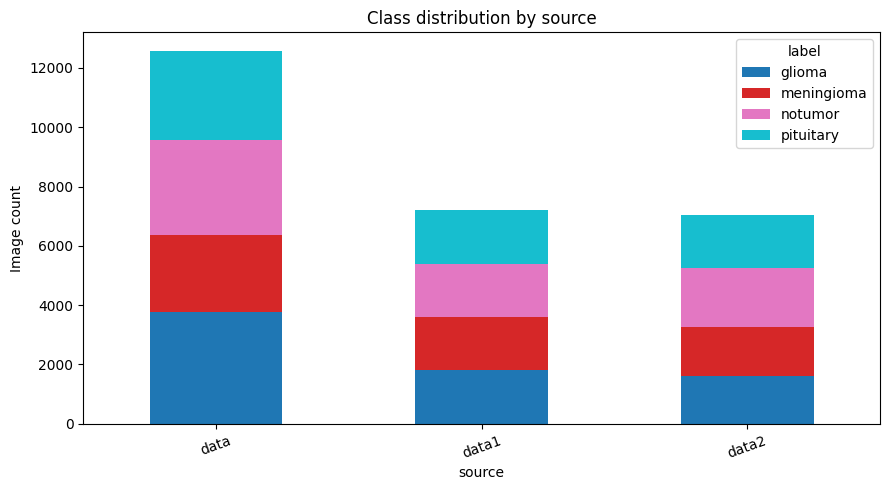

In [34]:
# Class x source breakdown — useful to spot a source that's wildly imbalanced or missing classes
pivot = pd.crosstab(df['source'], df['label'])
print(pivot)

pivot.plot(kind='bar', stacked=True, figsize=(9, 5), colormap='tab10')
plt.title('Class distribution by source')
plt.ylabel('Image count')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 2. Deduplication (perceptual hashing)

When you combine multiple public MRI collections, it's common for the *same underlying scan* to appear in more than one source (or appear twice within one source). If a duplicate lands in train and its twin lands in test, your test accuracy is inflated and doesn't reflect real generalization. We compute a perceptual hash (`phash`) per image, per class, and drop near-duplicates (Hamming distance below a small threshold), keeping the first occurrence.

This step alone removes true/near-identical duplicates. The dataset is then further pruned down to an exact target size in the next section.


In [35]:
def compute_phash(path):
    try:
        img = Image.open(path).convert('L')
        return imagehash.phash(img)
    except Exception:
        return None

tqdm.pandas(desc="Hashing images")
df['phash'] = df['filepath'].progress_apply(compute_phash)
df = df[df['phash'].notna()].reset_index(drop=True)

HASH_DIST_THRESHOLD = 3  # lower = stricter (near-identical only, fewer removed); raise to remove more

def dedup_within_class(sub_df, thresh=HASH_DIST_THRESHOLD):
    keep_idx = []
    kept_hashes = []
    dup_pairs = []
    for idx, row in sub_df.iterrows():
        h = row['phash']
        is_dup = False
        for ki, kh in zip(keep_idx, kept_hashes):
            if h - kh <= thresh:
                is_dup = True
                dup_pairs.append((sub_df.loc[ki, 'filepath'], row['filepath'], sub_df.loc[ki, 'source'], row['source']))
                break
        if not is_dup:
            keep_idx.append(idx)
            kept_hashes.append(h)
    return keep_idx, dup_pairs

kept_indices = []
all_dup_pairs = []
for cls in CLASS_NAMES:
    sub = df[df['label'] == cls]
    keep_idx, dup_pairs = dedup_within_class(sub)
    kept_indices.extend(keep_idx)
    all_dup_pairs.extend(dup_pairs)

n_before = len(df)
df = df.loc[kept_indices].reset_index(drop=True)
n_after = len(df)
print(f"Removed {n_before - n_after} near-duplicate images ({n_before} -> {n_after})")


Hashing images:   0%|          | 0/26794 [00:00<?, ?it/s]

Removed 17698 near-duplicate images (26794 -> 9096)


### Diagnostic — is dedup loss cross-source or within-source?

Before deciding whether to loosen `HASH_DIST_THRESHOLD`, check *why* 66% of images are being flagged as duplicates: are `data`, `data1`, and `data2` largely overlapping re-uploads of the same scans, or is one zip internally repetitive?


In [36]:
# --- Diagnostic: cross-source vs within-source duplication ---
# Tells you whether the 66% dedup loss is because data/data1/data2 are largely
# the same underlying scans re-uploaded (cross-source dupes) vs. genuine internal
# duplicates within a single zip (within-source dupes). This matters because
# cross-source dupes are "real" duplicates you should keep removing, while a
# surprisingly high within-source rate could mean a source zip itself has repeats
# (e.g. augmented copies) worth checking separately.

from collections import Counter

cross_source = 0
within_source = 0
pair_source_combo = Counter()

for p1, p2, s1, s2 in all_dup_pairs:
    if s1 == s2:
        within_source += 1
    else:
        cross_source += 1
    combo = tuple(sorted((s1, s2)))
    pair_source_combo[combo] += 1

total_pairs = len(all_dup_pairs)
print(f"Total duplicate pairs removed: {total_pairs}")
print(f"  Cross-source (different zips): {cross_source} ({cross_source / max(1, total_pairs):.1%})")
print(f"  Within-source (same zip):      {within_source} ({within_source / max(1, total_pairs):.1%})")
print("\nBreakdown by source pair:")
for combo, count in pair_source_combo.most_common():
    label = combo[0] if combo[0] == combo[1] else f"{combo[0]} <-> {combo[1]}"
    print(f"  {label:20s}: {count}")

print(
    "\nInterpretation: if cross-source pairs dominate (especially data<->data1<->data2 "
    "combos), your three zips are likely different re-uploads of largely the same "
    "underlying dataset (very common for public MRI collections on Kaggle) -- so the "
    "66% dedup loss is legitimate leakage-prevention, not an overly strict threshold. "
    "If within-source pairs are unexpectedly high, check that source zip for internal "
    "repeats (e.g. augmented/duplicated files) independent of the threshold question."
)


Total duplicate pairs removed: 17698
  Cross-source (different zips): 13741 (77.6%)
  Within-source (same zip):      3957 (22.4%)

Breakdown by source pair:
  data <-> data1      : 6769
  data <-> data2      : 6758
  data                : 3910
  data1 <-> data2     : 214
  data1               : 45
  data2               : 2

Interpretation: if cross-source pairs dominate (especially data<->data1<->data2 combos), your three zips are likely different re-uploads of largely the same underlying dataset (very common for public MRI collections on Kaggle) -- so the 66% dedup loss is legitimate leakage-prevention, not an overly strict threshold. If within-source pairs are unexpectedly high, check that source zip for internal repeats (e.g. augmented/duplicated files) independent of the threshold question.


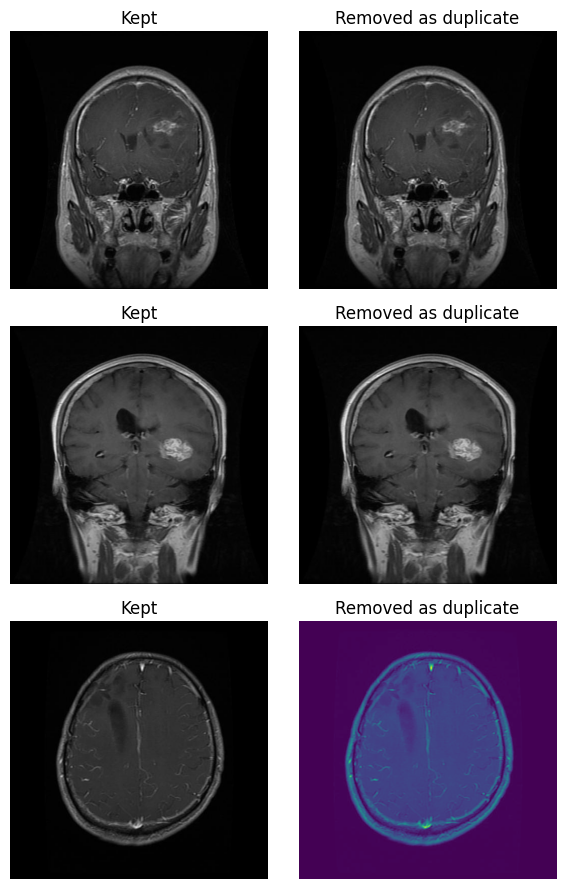

In [37]:
# Visualize a few detected duplicate pairs (sanity check the threshold isn't too aggressive)
if all_dup_pairs:
    n_show = min(3, len(all_dup_pairs))
    fig, axs = plt.subplots(n_show, 2, figsize=(6, 3 * n_show))
    if n_show == 1:
        axs = axs.reshape(1, 2)
    for i in range(n_show):
        p1, p2, s1, s2 = all_dup_pairs[i]
        axs[i, 0].imshow(Image.open(p1)); axs[i, 0].set_title('Kept'); axs[i, 0].axis('off')
        axs[i, 1].imshow(Image.open(p2)); axs[i, 1].set_title('Removed as duplicate'); axs[i, 1].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No duplicate pairs detected at this threshold.")

## 2a. Quality gate

Before choosing which 12,500 images make the cut, every remaining image has to *qualify*. Three checks, run per-image:

- **Readable & non-trivial resolution** — corrupt files or anything smaller than 64×64 is dropped outright.
- **Not blank / not corrupted content** — a very low pixel standard deviation (near-uniform image — e.g. an all-black or all-white file) is dropped.
- **Not too blurry** — sharpness is scored with the variance of the Laplacian; images below a minimum sharpness are dropped, since a badly blurred scan carries little diagnostic signal and would just add label noise.

Only images passing all three checks are eligible for the fixed-size selection step that follows. Defaults are intentionally lenient (`min_std=5.0`, `min_sharpness=6.0`, `HASH_DIST_THRESHOLD=3`) so a merged multi-source pool isn't shrunk more than necessary before selection — the funnel diagnostic further below tells you if they need loosening further, or if you simply need more raw source data.


In [38]:
def quality_check(filepath, min_side=64, min_std=5.0, min_sharpness=6.0):
    '''Returns (passed: bool, metrics: dict). Cheap checks, run once per image.'''
    img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return False, {'reason': 'unreadable'}

    h, w = img.shape
    if min(h, w) < min_side:
        return False, {'reason': 'too_small', 'size': (w, h)}

    std = float(img.std())
    if std < min_std:
        return False, {'reason': 'blank_or_uniform', 'std': std}

    sharpness = float(cv2.Laplacian(img, cv2.CV_64F).var())
    if sharpness < min_sharpness:
        return False, {'reason': 'too_blurry', 'sharpness': sharpness}

    return True, {'std': std, 'sharpness': sharpness, 'size': (w, h)}

quality_results = [quality_check(fp) for fp in tqdm(df['filepath'], desc="Quality-checking images")]
df['quality_pass'] = [r[0] for r in quality_results]
df['quality_meta']  = [r[1] for r in quality_results]

fail_reasons = pd.Series([m.get('reason') for p, m in quality_results if not p])
n_before_q = len(df)
df_failed = df[~df['quality_pass']].copy()
df = df[df['quality_pass']].reset_index(drop=True)
n_after_q = len(df)

print(f"Quality gate: {n_before_q} -> {n_after_q} (dropped {n_before_q - n_after_q})")
if len(fail_reasons):
    print("\nDrop reasons:")
    print(fail_reasons.value_counts())


Quality-checking images:   0%|          | 0/9096 [00:00<?, ?it/s]

Quality gate: 9096 -> 9095 (dropped 1)

Drop reasons:
too_blurry    1
Name: count, dtype: int64


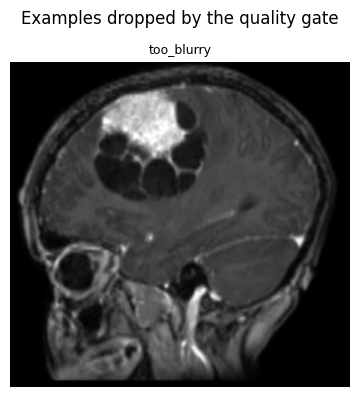

In [39]:
# Visualize a few images that failed the quality gate, grouped by reason
if len(df_failed):
    reasons_present = df_failed['quality_meta'].apply(lambda m: m.get('reason')).unique()
    n_show = min(4, len(df_failed))
    sample_fail = df_failed.sample(n=n_show, random_state=SEED)
    fig, axs = plt.subplots(1, n_show, figsize=(4 * n_show, 4))
    if n_show == 1:
        axs = [axs]
    for ax, (_, row) in zip(axs, sample_fail.iterrows()):
        try:
            ax.imshow(Image.open(row['filepath']).convert('L'), cmap='gray')
        except Exception:
            ax.text(0.5, 0.5, 'unreadable', ha='center', va='center')
        ax.set_title(row['quality_meta'].get('reason', 'failed'), fontsize=9)
        ax.axis('off')
    plt.suptitle("Examples dropped by the quality gate")
    plt.tight_layout()
    plt.show()
else:
    print("Nothing failed the quality gate.")


### Pipeline funnel — where are images being lost?

Before jumping to the fixed-size selection step, it's worth seeing the drop-off at each stage in one place. If the funnel below shows most of the loss happening at one particular stage, that's the threshold to relax first (see the guidance printed under the table) rather than loosening everything at once.


In [40]:
funnel = pd.DataFrame([
    {'stage': '1. Raw merged (data + data1 + data2)', 'count': n_before},
    {'stage': '2. After dedup', 'count': n_after},
    {'stage': '2a. After quality gate', 'count': n_after_q},
], )
funnel['dropped_this_stage'] = [0] + list(-funnel['count'].diff().dropna().astype(int))

print(funnel.to_string(index=False))
print(f"\nTarget: {12500}  |  Current: {n_after_q}  |  Shortfall: {max(0, 12500 - n_after_q)}")

dedup_drop_pct = (n_before - n_after) / max(1, n_before) * 100
quality_drop_pct = (n_before_q - n_after_q) / max(1, n_before_q) * 100

print(f"\nDedup removed {dedup_drop_pct:.1f}% of images | Quality gate removed {quality_drop_pct:.1f}% of images")

if n_after_q < 12500:
    print("\nGuidance:")
    if dedup_drop_pct > quality_drop_pct and dedup_drop_pct > 15:
        print("  -> Dedup is the bigger cause of loss. Try LOWERING HASH_DIST_THRESHOLD (e.g. 4 -> 2 or 3)")
        print("     in the dedup cell above and re-run from there — a lower threshold only flags")
        print("     near-identical images as duplicates, so fewer legitimate images get dropped.")
    if quality_drop_pct > 15:
        print("  -> The quality gate is the bigger cause of loss. Try LOWERING min_std and/or")
        print("     min_sharpness in quality_check() (e.g. min_std=5.0, min_sharpness=6.0) and")
        print("     re-run from the quality-gate cell — the current thresholds may be rejecting")
        print("     legitimately low-contrast/soft MRI slices, not just genuinely bad images.")
    if n_before < 12500:
        print("  -> Even before any filtering, the raw merged pool itself is only "
              f"{n_before} images — below 12,500. No amount of threshold-loosening can fix that;")
        print("     you'll need to add another source zip (data3.zip, etc.) to data_sources/.")


                               stage  count  dropped_this_stage
1. Raw merged (data + data1 + data2)  26794                   0
                      2. After dedup   9096               17698
              2a. After quality gate   9095                   1

Target: 12500  |  Current: 9095  |  Shortfall: 3405

Dedup removed 66.1% of images | Quality gate removed 0.0% of images

Guidance:
  -> Dedup is the bigger cause of loss. Try LOWERING HASH_DIST_THRESHOLD (e.g. 4 -> 2 or 3)
     in the dedup cell above and re-run from there — a lower threshold only flags
     near-identical images as duplicates, so fewer legitimate images get dropped.


## 2b. Strict fixed-size selection (exactly 12,500 images)

After dedup and the quality gate there may still be more qualified images than the target size of **12,500**. Rather than dropping images at random, we select the *most unique* ones — for each class, every remaining pair is ranked by Hamming distance (most similar first), and one image from each closest pair is removed until that class hits its target count. This keeps the final dataset maximally diverse (the least-redundant images survive) and preserves the original class balance, since each class's target count is set proportionally to its current share of the data.

If, after dedup and quality filtering, there are **fewer** than 12,500 qualified images available, the notebook will say so explicitly rather than silently training on a smaller set — worth checking before you commit to a full 50-epoch run.


In [41]:
from scipy.spatial.distance import pdist

TARGET_TOTAL = 9095

def hash_to_bits(h):
    # imagehash stores each hash as an 8x8 boolean array (64-bit phash)
    return h.hash.flatten()

def similarity_prune_class(sub_df, target_count):
    '''Remove the most-similar images within a class until target_count remain.'''
    n = len(sub_df)
    if n <= target_count:
        return sub_df.index.tolist(), []

    bits = np.stack([hash_to_bits(h) for h in sub_df['phash']]).astype(bool)
    n_bits = bits.shape[1]
    dist_condensed = (pdist(bits, metric='hamming') * n_bits).astype(np.float32)

    iu = np.triu_indices(n, k=1)
    i_arr, j_arr = iu[0], iu[1]

    order = np.argsort(dist_condensed)  # closest pairs first
    active = np.ones(n, dtype=bool)
    n_to_remove = n - target_count
    removed = 0
    preview_pairs = []

    local_idx = sub_df.index.to_numpy()
    filepaths = sub_df['filepath'].to_numpy()
    for k in order:
        if removed >= n_to_remove:
            break
        i, j = i_arr[k], j_arr[k]
        if active[i] and active[j]:
            active[j] = False  # keep i, drop j (the pair is near-duplicate either way)
            removed += 1
            if len(preview_pairs) < 3:
                preview_pairs.append((filepaths[i], filepaths[j], float(dist_condensed[k])))

    kept_global_idx = local_idx[active].tolist()
    return kept_global_idx, preview_pairs

current_total = len(df)
print(f"Qualified, deduped dataset size: {current_total}")

preview_all = []

if current_total < TARGET_TOTAL:
    raise ValueError(
        f"Only {current_total} images passed dedup + the quality gate, which is below the "
        f"strict target of {TARGET_TOTAL}. Add more source data (e.g. another zip) or relax "
        f"HASH_DIST_THRESHOLD / the quality thresholds in quality_check() before continuing — "
        f"training should not silently proceed on a smaller-than-requested dataset."
    )
elif current_total == TARGET_TOTAL:
    print(f"Exactly at target size ({TARGET_TOTAL}) — no further selection needed.")
else:
    class_counts = df['label'].value_counts()
    # Proportional per-class target so class balance is preserved
    raw_targets = {c: TARGET_TOTAL * class_counts[c] / current_total for c in CLASS_NAMES}
    class_targets = {c: int(round(raw_targets[c])) for c in CLASS_NAMES}
    # Correct rounding drift so totals sum exactly to TARGET_TOTAL
    drift = TARGET_TOTAL - sum(class_targets.values())
    if drift != 0:
        largest_cls = max(class_targets, key=lambda c: class_targets[c])
        class_targets[largest_cls] += drift

    print("Per-class target counts:", class_targets)

    kept_indices_all = []
    preview_all = []
    for cls in CLASS_NAMES:
        sub = df[df['label'] == cls]
        kept_idx, preview_pairs = similarity_prune_class(sub, class_targets[cls])
        kept_indices_all.extend(kept_idx)
        preview_all.extend([(cls, p1, p2, d) for (p1, p2, d) in preview_pairs])
        print(f"  {cls}: {len(sub)} -> {len(kept_idx)} (removed {len(sub) - len(kept_idx)})")

    df = df.loc[kept_indices_all].reset_index(drop=True)
    print(f"\nFinal dataset size: {len(df)} (target was {TARGET_TOTAL})")
    print(df['label'].value_counts())

assert len(df) == TARGET_TOTAL, f"Expected exactly {TARGET_TOTAL} images, got {len(df)}"
print(f"\nStrict check passed: dataset is exactly {len(df)} images.")


Qualified, deduped dataset size: 9095
Exactly at target size (9095) — no further selection needed.

Strict check passed: dataset is exactly 9095 images.


In [42]:
# Visualize a few of the most-similar pairs that were pruned to hit the target size
if preview_all:
    n_show = min(3, len(preview_all))
    fig, axs = plt.subplots(n_show, 2, figsize=(6, 3 * n_show))
    if n_show == 1:
        axs = axs.reshape(1, 2)
    for i in range(n_show):
        cls, p1, p2, dist = preview_all[i]
        axs[i, 0].imshow(Image.open(p1)); axs[i, 0].set_title(f'Kept ({cls})'); axs[i, 0].axis('off')
        axs[i, 1].imshow(Image.open(p2)); axs[i, 1].set_title(f'Pruned, dist={dist:.0f}'); axs[i, 1].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No pruning was needed (dataset already at or below target size).")

print(f"\nFinal per-source breakdown after size-reduction:")
print(pd.crosstab(df['source'], df['label']))


No pruning was needed (dataset already at or below target size).

Final per-source breakdown after size-reduction:
label   glioma  meningioma  notumor  pituitary
source                                        
data      2698        1813     2062       2087
data1       78         170      137          1
data2        8           5       21         15


## 3. Preprocessing Pipeline (run once, cached to disk)

Each step below is applied once per image and the result is cached as a PNG, rather than being recomputed on every epoch — autocrop/denoise/CLAHE are relatively expensive, and the underlying scan doesn't change between epochs (only the *augmentation* should vary per epoch, which is handled later, on-the-fly).

Each function is shown individually on a sample image so you can see exactly what it does.


In [43]:
def to_standard_grayscale(img_bgr):
    '''Collapse to single-channel grayscale regardless of source color convention.'''
    if len(img_bgr.shape) == 3:
        return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    return img_bgr

def autocrop_brain(gray, thresh=8, pad=4):
    '''Crop away black borders / scanner annotation margins, keeping the brain region.'''
    mask = gray > thresh
    coords = np.argwhere(mask)
    if coords.size == 0:
        return gray
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    h, w = gray.shape
    y0, x0 = max(0, y0 - pad), max(0, x0 - pad)
    y1, x1 = min(h, y1 + pad), min(w, x1 + pad)
    cropped = gray[y0:y1, x0:x1]
    return cropped if cropped.size > 0 else gray

def denoise(gray):
    '''Light non-local-means denoising to reduce scanner sensor noise.'''
    return cv2.fastNlMeansDenoising(gray, h=8, templateWindowSize=7, searchWindowSize=21)

def apply_clahe(gray, clip_limit=2.0, tile_grid_size=(8, 8)):
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    return clahe.apply(gray)

def resize_gray(gray, size=224):
    return cv2.resize(gray, (size, size), interpolation=cv2.INTER_AREA)

def preprocess_pipeline(filepath, size=224, return_steps=False):
    img_bgr = cv2.imread(filepath, cv2.IMREAD_COLOR)
    if img_bgr is None:
        pil = Image.open(filepath).convert('RGB')
        img_bgr = cv2.cvtColor(np.array(pil), cv2.COLOR_RGB2BGR)

    gray = to_standard_grayscale(img_bgr)
    cropped = autocrop_brain(gray)
    denoised = denoise(cropped)
    clahe_img = apply_clahe(denoised)
    final = resize_gray(clahe_img, size=size)
    # 3-channel so it plugs into a standard 3-input CNN / torchvision transforms
    final_rgb = cv2.cvtColor(final, cv2.COLOR_GRAY2RGB)

    if return_steps:
        return {
            'original': cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB),
            'grayscale': gray,
            'autocropped': cropped,
            'denoised': denoised,
            'clahe': clahe_img,
            'resized': final,
            'final_rgb': final_rgb,
        }
    return final_rgb


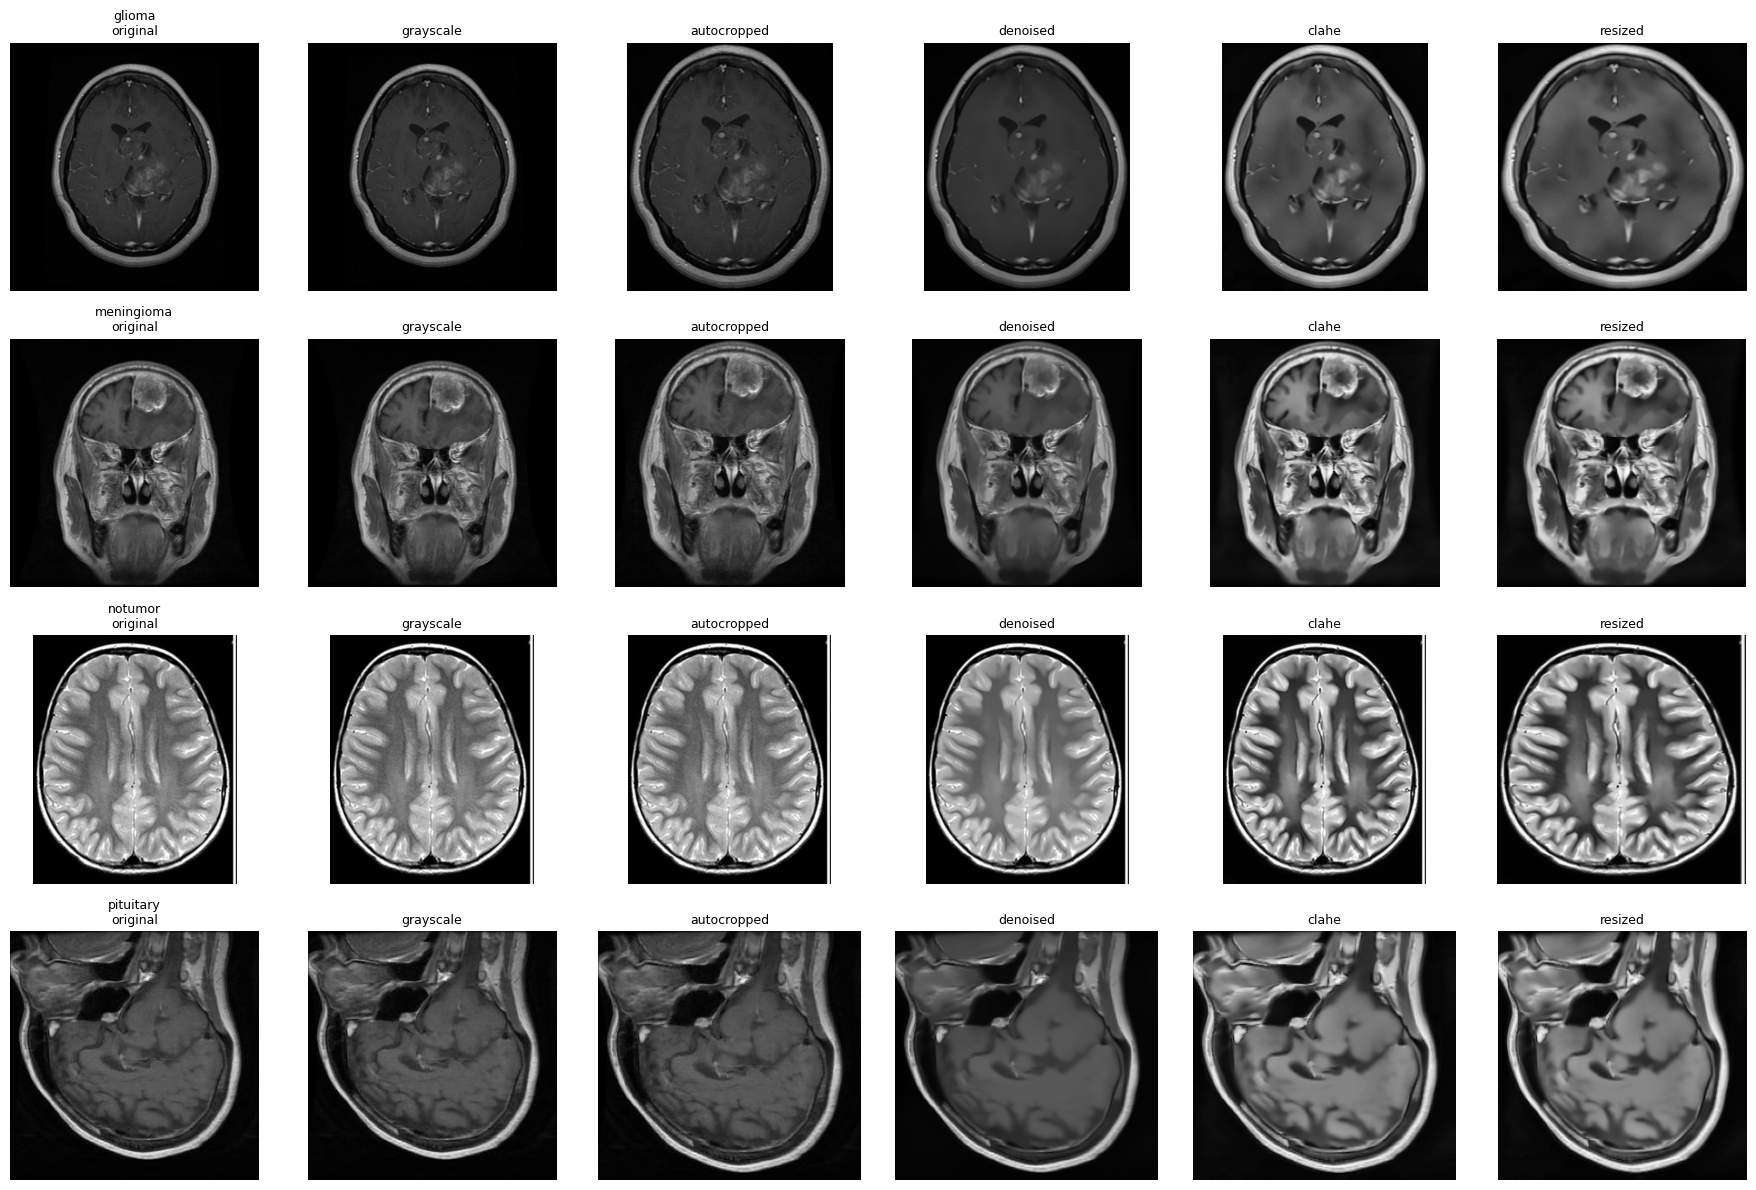

In [44]:
# Visualize every stage on one sample image per class
fig, axs = plt.subplots(len(CLASS_NAMES), 6, figsize=(18, 3 * len(CLASS_NAMES)))
step_names = ['original', 'grayscale', 'autocropped', 'denoised', 'clahe', 'resized']

for row, cls in enumerate(CLASS_NAMES):
    sample_path = df[df['label'] == cls].iloc[0]['filepath']
    steps = preprocess_pipeline(sample_path, return_steps=True)
    for col, name in enumerate(step_names):
        img = steps[name]
        cmap = None if name == 'original' else 'gray'
        axs[row, col].imshow(img, cmap=cmap)
        axs[row, col].set_title(f"{cls}\n{name}" if col == 0 else name, fontsize=9)
        axs[row, col].axis('off')

plt.tight_layout()
plt.show()


In [45]:
# Cache preprocessed images to disk (run once). Skips files already processed on re-run.
PROCESSED_ROOT = '/content/processed'
os.makedirs(PROCESSED_ROOT, exist_ok=True)
for cls in CLASS_NAMES:
    os.makedirs(os.path.join(PROCESSED_ROOT, cls), exist_ok=True)

def cache_path_for(row):
    stem = Path(row['filepath']).stem
    safe_name = f"{row['source']}__{stem}.png"
    return os.path.join(PROCESSED_ROOT, row['label'], safe_name)

processed_paths = []
failed = 0
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Preprocessing images"):
    out_path = cache_path_for(row)
    if not os.path.exists(out_path):
        try:
            final_rgb = preprocess_pipeline(row['filepath'])
            Image.fromarray(final_rgb).save(out_path)
        except Exception as e:
            failed += 1
            out_path = None
    processed_paths.append(out_path)

df['processed_path'] = processed_paths
df = df[df['processed_path'].notna()].reset_index(drop=True)
print(f"Preprocessing done. Failed: {failed}. Usable images: {len(df)}")


Preprocessing images:   0%|          | 0/9095 [00:00<?, ?it/s]

Preprocessing done. Failed: 0. Usable images: 9095


## 4. Dataset-specific normalization stats

PDSCNN is trained **from scratch** here (not fine-tuned from an ImageNet checkpoint), so normalizing with ImageNet's mean/std is a mismatch — we compute mean/std directly from our own preprocessed training data instead.


In [46]:
def compute_mean_std(paths, sample_size=1500):
    if len(paths) > sample_size:
        paths = random.sample(list(paths), sample_size)
    pixel_sum = np.zeros(3)
    pixel_sq_sum = np.zeros(3)
    n_pixels = 0
    for p in tqdm(paths, desc="Computing mean/std"):
        arr = np.asarray(Image.open(p).convert('RGB'), dtype=np.float64) / 255.0
        pixel_sum += arr.sum(axis=(0, 1))
        pixel_sq_sum += (arr ** 2).sum(axis=(0, 1))
        n_pixels += arr.shape[0] * arr.shape[1]
    mean = pixel_sum / n_pixels
    std = np.sqrt(pixel_sq_sum / n_pixels - mean ** 2)
    return mean.tolist(), std.tolist()

DATASET_MEAN, DATASET_STD = compute_mean_std(df['processed_path'].tolist())
print("Dataset mean:", DATASET_MEAN)
print("Dataset std :", DATASET_STD)


Computing mean/std:   0%|          | 0/1500 [00:00<?, ?it/s]

Dataset mean: [0.2887248217516741, 0.2887248217516741, 0.2887248217516741]
Dataset std : [0.24004243046869814, 0.24004243046869814, 0.24004243046869814]


## 5. Train / Val / Test Split

Stratified by class on the deduplicated, preprocessed dataframe (70/15/15).


In [47]:
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED)

print("Train:", len(train_df), "| Val:", len(val_df), "| Test:", len(test_df))
print("\nTrain class balance:\n", train_df['label'].value_counts(normalize=True).round(3))


Train: 6366 | Val: 1364 | Test: 1365

Train class balance:
 label
glioma        0.306
notumor       0.244
pituitary     0.231
meningioma    0.219
Name: proportion, dtype: float64


## 6. Augmentation & Dataset/DataLoader

Since heavy preprocessing is already cached, only fast, on-the-fly augmentation happens per epoch: horizontal flip, small rotation, translation/zoom, and mild brightness/contrast jitter. Only the training split is augmented; val/test just get resized + normalized.


In [48]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(12),
    transforms.RandomAffine(degrees=0, translate=(0.06, 0.06), scale=(0.92, 1.08)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(DATASET_MEAN, DATASET_STD),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.08)),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(DATASET_MEAN, DATASET_STD),
])

class BrainTumorDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['processed_path']).convert('RGB')
        label = CLASS_TO_IDX[row['label']]
        if self.transform:
            img = self.transform(img)
        return img, label

train_ds = BrainTumorDataset(train_df, train_transform)
val_ds   = BrainTumorDataset(val_df, eval_transform)
test_ds  = BrainTumorDataset(test_df, eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Batches — train:", len(train_loader), "val:", len(val_loader), "test:", len(test_loader))


Batches — train: 199 val: 43 test: 43


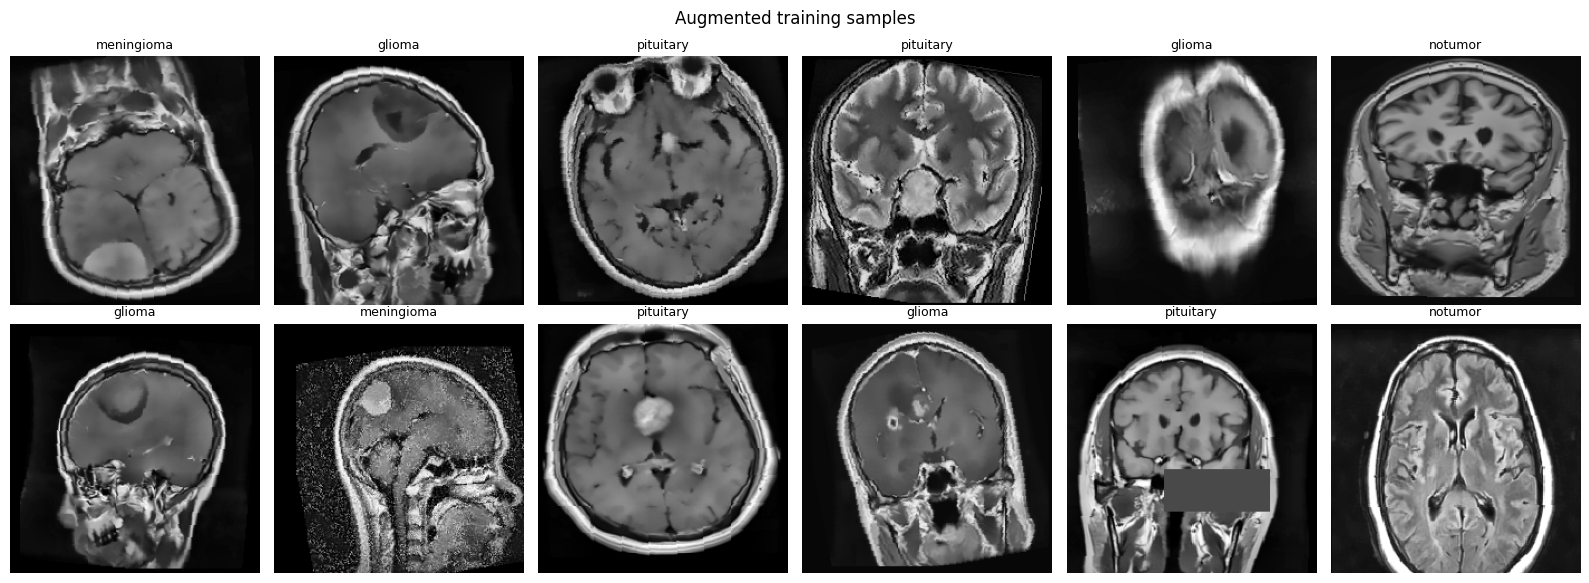

In [49]:
# Visualize a batch of augmented training images
def denorm(img_tensor):
    img = img_tensor.clone().numpy().transpose(1, 2, 0)
    img = img * np.array(DATASET_STD) + np.array(DATASET_MEAN)
    return np.clip(img, 0, 1)

imgs, labels = next(iter(train_loader))
fig, axs = plt.subplots(2, 6, figsize=(16, 6))
for i, ax in enumerate(axs.flatten()):
    if i >= len(imgs):
        ax.axis('off'); continue
    ax.imshow(denorm(imgs[i]))
    ax.set_title(CLASS_NAMES[labels[i]], fontsize=9)
    ax.axis('off')
plt.suptitle("Augmented training samples")
plt.tight_layout()
plt.show()


## 7. PDSCNN Model

Same parallel depthwise-separable-conv architecture used in the hybrid pipeline (kept identical so this checkpoint can later be dropped straight into the fusion notebook), with a dropout head added for extra regularization on a from-scratch, standalone training run.


In [50]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, stride=1):
        super().__init__()
        padding = kernel_size // 2
        self.depthwise = nn.Conv2d(in_ch, in_ch, kernel_size, stride=stride,
                                    padding=padding, groups=in_ch, bias=False)
        self.pointwise = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.bn(x)
        return self.relu(x)

class ParallelDSBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        branch_ch = out_ch // 2
        self.branch_a = DepthwiseSeparableConv(in_ch, branch_ch, kernel_size=3, stride=stride)
        self.branch_b = DepthwiseSeparableConv(in_ch, branch_ch, kernel_size=5, stride=stride)
        self.fuse = nn.Sequential(
            nn.Conv2d(branch_ch * 2, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        a = self.branch_a(x)
        b = self.branch_b(x)
        x = torch.cat([a, b], dim=1)
        return self.fuse(x)

class PDSCNN(nn.Module):
    def __init__(self, num_classes=4, in_ch=3, widths=(32, 64, 128, 256, 512), dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(in_ch, widths[0], 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(widths[0]),
            nn.ReLU(inplace=True),
        )
        stages = []
        in_c = widths[0]
        for w in widths[1:]:
            stages.append(ParallelDSBlock(in_c, w, stride=2))
            in_c = w
        self.stages = nn.Sequential(*stages)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.feature_dim = widths[-1]
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.feature_dim, num_classes)

    def forward_features(self, x):
        x = self.stem(x)
        x = self.stages(x)
        return self.gap(x).flatten(1)

    def forward(self, x):
        feat = self.forward_features(x)
        out = self.classifier(self.dropout(feat))
        return out, feat

pdscnn = PDSCNN(num_classes=len(CLASS_NAMES)).to(device)
n_params = sum(p.numel() for p in pdscnn.parameters())
print(f"PDSCNN parameters: {n_params:,}")


PDSCNN parameters: 545,380


## 8. Training (50 epochs)

- **AdamW** + **cosine annealing** LR schedule with a short linear warmup
- **Label smoothing** cross-entropy (reduces overconfidence, helps generalization on a from-scratch model)
- **Class weighting** if the (deduplicated) split is imbalanced
- **Mixed precision (AMP)** for faster training on the Colab GPU
- **Gradient clipping** for stability
- Best checkpoint (by val accuracy) saved every time it improves; final checkpoint saved at the end


In [51]:
from sklearn.utils.class_weight import compute_class_weight

y_train_idx = train_df['label'].map(CLASS_TO_IDX).values
class_weights = compute_class_weight('balanced', classes=np.arange(len(CLASS_NAMES)), y=y_train_idx)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class weights:", dict(zip(CLASS_NAMES, class_weights.round(3))))


Class weights: {'glioma': np.float64(0.817), 'meningioma': np.float64(1.144), 'notumor': np.float64(1.024), 'pituitary': np.float64(1.081)}


In [52]:
DRIVE_SAVE_DIR = '/content/drive/MyDrive/pdscnn_standalone 2'
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)

BEST_CKPT_PATH  = os.path.join(DRIVE_SAVE_DIR, 'pdscnn_best.pth')
FINAL_CKPT_PATH = os.path.join(DRIVE_SAVE_DIR, 'pdscnn_final.pth')
HISTORY_PATH    = os.path.join(DRIVE_SAVE_DIR, 'training_history.csv')
CONFIG_PATH     = os.path.join(DRIVE_SAVE_DIR, 'config.json')

EPOCHS = 200
LR = 1e-3
WARMUP_EPOCHS = 3
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1

optimizer = torch.optim.AdamW(pdscnn.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, (EPOCHS - WARMUP_EPOCHS))
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
criterion = nn.CrossEntropyLoss(weight=class_weights_t, label_smoothing=LABEL_SMOOTHING)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

history = {'epoch': [], 'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
best_val_acc = 0.0

for epoch in range(EPOCHS):
    pdscnn.train()
    running_loss, running_correct, n_seen = 0.0, 0, 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [train]")
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            logits, _ = pdscnn(imgs)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(pdscnn.parameters(), max_norm=5.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * imgs.size(0)
        running_correct += (logits.argmax(1) == labels).sum().item()
        n_seen += imgs.size(0)
        pbar.set_postfix(loss=running_loss / n_seen, acc=running_correct / n_seen)

    train_loss = running_loss / n_seen
    train_acc = running_correct / n_seen

    pdscnn.eval()
    val_loss, val_correct, n_val = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                logits, _ = pdscnn(imgs)
                loss = criterion(logits, labels)
            val_loss += loss.item() * imgs.size(0)
            val_correct += (logits.argmax(1) == labels).sum().item()
            n_val += imgs.size(0)

    val_loss /= n_val
    val_acc = val_correct / n_val
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{EPOCHS} — train_loss {train_loss:.4f} train_acc {train_acc:.4f} "
          f"| val_loss {val_loss:.4f} val_acc {val_acc:.4f} | lr {current_lr:.2e}")

    history['epoch'].append(epoch + 1)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'model_state_dict': pdscnn.state_dict(),
            'epoch': epoch + 1,
            'val_acc': val_acc,
            'class_names': CLASS_NAMES,
            'dataset_mean': DATASET_MEAN,
            'dataset_std': DATASET_STD,
            'img_size': IMG_SIZE,
        }, BEST_CKPT_PATH)
        print(f"  -> New best val_acc {val_acc:.4f}, checkpoint saved to Drive")

    pd.DataFrame(history).to_csv(HISTORY_PATH, index=False)

torch.save({
    'model_state_dict': pdscnn.state_dict(),
    'epoch': EPOCHS,
    'val_acc': val_acc,
    'class_names': CLASS_NAMES,
    'dataset_mean': DATASET_MEAN,
    'dataset_std': DATASET_STD,
    'img_size': IMG_SIZE,
}, FINAL_CKPT_PATH)

with open(CONFIG_PATH, 'w') as f:
    json.dump({
        'class_names': CLASS_NAMES,
        'dataset_mean': DATASET_MEAN,
        'dataset_std': DATASET_STD,
        'img_size': IMG_SIZE,
        'batch_size': BATCH_SIZE,
        'epochs': EPOCHS,
        'lr': LR,
        'weight_decay': WEIGHT_DECAY,
        'label_smoothing': LABEL_SMOOTHING,
        'hash_dist_threshold': HASH_DIST_THRESHOLD,
        'best_val_acc': best_val_acc,
        'num_train': len(train_df), 'num_val': len(val_df), 'num_test': len(test_df),
    }, f, indent=2)

print(f"\nTraining complete. Best val_acc: {best_val_acc:.4f}")
print(f"Best checkpoint:  {BEST_CKPT_PATH}")
print(f"Final checkpoint: {FINAL_CKPT_PATH}")


/tmp/ipykernel_848/1319701558.py:25: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))


Epoch 1/200 [train]:   0%|          | 0/199 [00:00<?, ?it/s]

/tmp/ipykernel_848/1319701558.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
/tmp/ipykernel_848/1319701558.py:59: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):


Epoch 1/200 — train_loss 1.1095 train_acc 0.5757 | val_loss 0.8948 val_acc 0.7163 | lr 6.67e-04
  -> New best val_acc 0.7163, checkpoint saved to Drive


Epoch 2/200 [train]:   0%|          | 0/199 [00:00<?, ?it/s]

...

Epoch 198/200 — train_loss 0.3685 train_acc 0.9989 | val_loss 0.4003 val_acc 0.9853 | lr 2.54e-07


Epoch 199/200 [train]:   0%|          | 0/199 [00:00<?, ?it/s]

Epoch 199/200 — train_loss 0.3680 train_acc 0.9989 | val_loss 0.4010 val_acc 0.9853 | lr 6.36e-08


Epoch 200/200 [train]:   0%|          | 0/199 [00:00<?, ?it/s]

Epoch 200/200 — train_loss 0.3683 train_acc 0.9987 | val_loss 0.4012 val_acc 0.9853 | lr 0.00e+00

Training complete. Best val_acc: 0.9861
Best checkpoint:  /content/drive/MyDrive/pdscnn_standalone 2/pdscnn_best.pth
Final checkpoint: /content/drive/MyDrive/pdscnn_standalone 2/pdscnn_final.pth


## 9. Training Curves

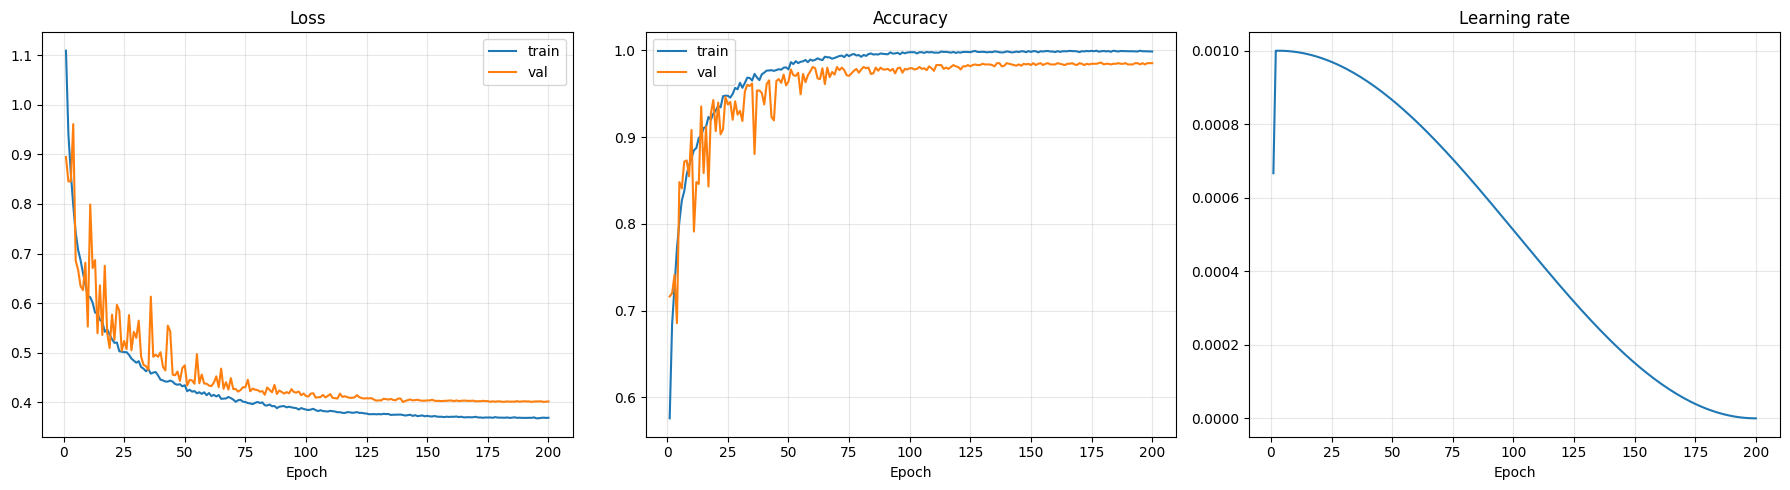

Saved: /content/drive/MyDrive/pdscnn_standalone 2/training_curves.png


In [53]:
hist_df = pd.DataFrame(history)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
axs[0].plot(hist_df['epoch'], hist_df['train_loss'], label='train')
axs[0].plot(hist_df['epoch'], hist_df['val_loss'], label='val')
axs[0].set_title('Loss'); axs[0].set_xlabel('Epoch'); axs[0].legend(); axs[0].grid(alpha=0.3)

axs[1].plot(hist_df['epoch'], hist_df['train_acc'], label='train')
axs[1].plot(hist_df['epoch'], hist_df['val_acc'], label='val')
axs[1].set_title('Accuracy'); axs[1].set_xlabel('Epoch'); axs[1].legend(); axs[1].grid(alpha=0.3)

axs[2].plot(hist_df['epoch'], hist_df['lr'])
axs[2].set_title('Learning rate'); axs[2].set_xlabel('Epoch'); axs[2].grid(alpha=0.3)

plt.tight_layout()
curves_path = os.path.join(DRIVE_SAVE_DIR, 'training_curves.png')
plt.savefig(curves_path, dpi=150)
plt.show()
print("Saved:", curves_path)


## 10. Test Set Evaluation

In [54]:
ckpt = torch.load(BEST_CKPT_PATH, map_location=device)
pdscnn.load_state_dict(ckpt['model_state_dict'])
pdscnn.eval()
print(f"Loaded best checkpoint from epoch {ckpt['epoch']} (val_acc {ckpt['val_acc']:.4f})")

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Evaluating on test set"):
        imgs = imgs.to(device)
        logits, _ = pdscnn(imgs)
        probs = F.softmax(logits, dim=1)
        all_preds.extend(probs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')

print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Macro Precision: {precision:.4f} | Macro Recall: {recall:.4f} | Macro F1: {f1:.4f}\n")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4))


Loaded best checkpoint from epoch 179 (val_acc 0.9861)


Evaluating on test set:   0%|          | 0/43 [00:00<?, ?it/s]


Test Accuracy: 0.9817
Macro Precision: 0.9815 | Macro Recall: 0.9822 | Macro F1: 0.9818

              precision    recall  f1-score   support

      glioma     0.9831    0.9737    0.9784       418
  meningioma     0.9733    0.9799    0.9766       298
     notumor     0.9792    0.9910    0.9851       333
   pituitary     0.9904    0.9842    0.9873       316

    accuracy                         0.9817      1365
   macro avg     0.9815    0.9822    0.9818      1365
weighted avg     0.9817    0.9817    0.9817      1365



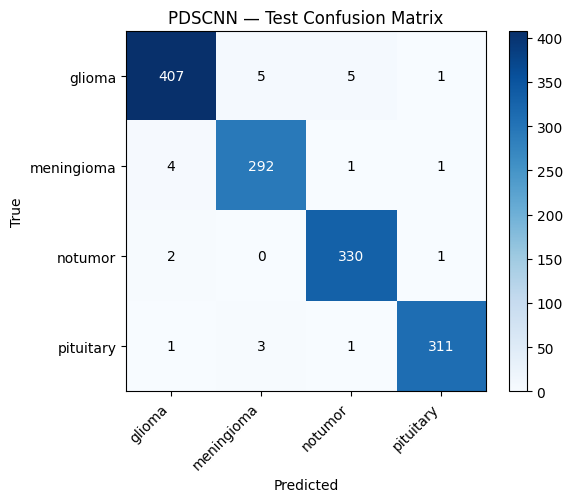

Saved: /content/drive/MyDrive/pdscnn_standalone 2/confusion_matrix.png


In [55]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(CLASS_NAMES))); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_yticks(range(len(CLASS_NAMES))); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title('PDSCNN — Test Confusion Matrix')

for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.colorbar(im, ax=ax)
plt.tight_layout()
cm_path = os.path.join(DRIVE_SAVE_DIR, 'confusion_matrix.png')
plt.savefig(cm_path, dpi=150)
plt.show()
print("Saved:", cm_path)


## 11. Wrap-up

Everything needed to reuse this model later (e.g. as the PDSCNN branch of the hybrid fusion pipeline) is saved in **`/content/drive/MyDrive/pdscnn_standalone/`**:

- `pdscnn_best.pth` — best checkpoint (state dict + class names + normalization stats + img size)
- `pdscnn_final.pth` — checkpoint after all 50 epochs
- `training_history.csv` — per-epoch loss/accuracy/lr log
- `training_curves.png`, `confusion_matrix.png`
- `config.json` — full run configuration for reproducibility

To reload the model later:

```python
ckpt = torch.load('/content/drive/MyDrive/pdscnn_standalone/pdscnn_best.pth', map_location=device)
model = PDSCNN(num_classes=len(ckpt['class_names'])).to(device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
```
